<a href="https://colab.research.google.com/github/LuisaFernandaOchoa/prueba_luisa_ochoa/blob/main/prueba_modulo_1_luisa_ochoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prueba Tecnica

**Esta prueba técnica puede ser resuelta en cualquier entorno que le parezca adecuado**

Una empresa de retail de moda subcontrata la fabricación de sus colecciones. Actualmente, la asignación de las órdenes de trabajo a los talleres proveedores se realiza manualmente, un proceso que resulta ineficiente y no garantiza la maximización del valor de la producción.
## 🎯 El Desafío: Sistema de Asignación de Órdenes Óptimo
El objetivo es diseñar y formular un Sistema de Decisión que automatice la asignación de órdenes de trabajo a los talleres proveedores, buscando maximizar el valor y la eficiencia de la producción, mientras se respeta la capacidad y especialización de cada taller, y permita realizar escenarios tipo What-if.

Teniendo en cuenta:
- Maximizar la cantidad de órdenes de trabajo a entregar
- Cada orden de trabajo tiene un peso diferente que varía del 1 al 3, donde 3 es el más importante
- Todos los proveedores no son igual de importantes, los que tengan más experiencia con un material deberían seguir manejando ese material, además los tenemos clasificados de acuerdo a su importancia.
- En la asignación de trabajos si un material se le es asignado a un proveedor, todas las órdenes de trabajo de ese material deberán ser asignadas a ese mismo proveedor.
- Una vez asignada(s) la(s) ordene(s) de trabajo a un proveedor, se necesita saber el orden en el que deberia producir las ordenes de trabajo para minimizar el time to market de acuerdo a la prioridad


El archivo de 'Historial_de_ordenes.zip encontras 4 archivos:
1. Ordenes de trabajo: En este archivo se encuentran las órdenes de trabajo que se deben asignar a los proveedores
2. Lista de proveedores: Son los datos correspondientes a los proveedores activos, su clasificación de acuerdo al tipo de producto.
3. Historial de ordenes: Son los datos correspondientes cuantas órdenes a producido en el pasado cada proveedor de acuerdo al tipo de material
4. Capacidad de proveedores: Es el tiempo que tienen los proveedores para ejecutar las órdenes de trabajo en minutos.


# Sistema de Asignación Óptima de Órdenes de Trabajo
**Autor:** Luisa Fernanda Ochoa  
**Rol:** Aspirante a Analista de Datos Junior SUMMAN

**Objetivo:** Desarrollar un modelo de optimización para asignar órdenes de trabajo a proveedores garantizando la maximización del valor, respetando restricciones de capacidad, especialización por material y secuenciación de producción.

#1. Importar librerías y cargar datasets

En esta sección se importan las librerías necesarias para la exploración de los datos y se cargan los cuatro datasets desde el repositorio público mediante sus URLs en bruto (*raw*), garantizando la reproducibilidad completa del análisis.

In [ ]:
# Importación de librerías para exploración inicial
import pandas as pd
import numpy as np

# Definición de URLs Raw de GitHub
url_ordenes = "https://raw.githubusercontent.com/LuisaFernandaOchoa/prueba_luisa_ochoa/refs/heads/main/data/Ordenes_de_trabajo.csv"
url_proveedores = "https://raw.githubusercontent.com/LuisaFernandaOchoa/prueba_luisa_ochoa/refs/heads/main/data/Lista_de_proveedores.csv"
url_historial = "https://raw.githubusercontent.com/LuisaFernandaOchoa/prueba_luisa_ochoa/refs/heads/main/data/Historial_de_ordenes.csv"
url_capacidad = "https://raw.githubusercontent.com/LuisaFernandaOchoa/prueba_luisa_ochoa/refs/heads/main/data/Capacidad_de_proveedores.csv"

# Carga de datasets en DataFrames de Pandas
df_ordenes = pd.read_csv(url_ordenes)
df_proveedores = pd.read_csv(url_proveedores)
df_historial = pd.read_csv(url_historial)
df_capacidad = pd.read_csv(url_capacidad)

print("Archivos cargados")

Archivos cargados


In [ ]:
# Inspección básica de los datasets cargados
datasets = {
    "Órdenes de Trabajo": df_ordenes,
    "Lista de Proveedores": df_proveedores,
    "Historial de Órdenes": df_historial,
    "Capacidad de Proveedores": df_capacidad
}

print("VALIDACIÓN DE ARCHIVOS CARGADOS")
for nombre, df in datasets.items():
    print(f" Dataset: {nombre}")
    print(f"   - Filas: {df.shape[0]}")
    print(f"   - Columnas: {df.shape[1]}")
    print(f"   - Nombres de columnas: {list(df.columns)}")
    print()

VALIDACIÓN DE ARCHIVOS CARGADOS
 Dataset: Órdenes de Trabajo
   - Filas: 802
   - Columnas: 7
   - Nombres de columnas: ['Orden', 'Unidades de la OP', 'Material', 'Denominacion Tipo de producto', 'SAM', 'Prioridad', 'Minutos totales de la orden']

 Dataset: Lista de Proveedores
   - Filas: 299
   - Columnas: 3
   - Nombres de columnas: ['ID', 'Descripcion clasificacion proveedor', 'Denominacion Tipo de producto']

 Dataset: Historial de Órdenes
   - Filas: 39162
   - Columnas: 3
   - Nombres de columnas: ['ID', 'Material', 'Unidades fabricadas']

 Dataset: Capacidad de Proveedores
   - Filas: 211
   - Columnas: 2
   - Nombres de columnas: ['ID', 'Capacidad Disponible']



## 2. Exploración y Validación de los Datos

En esta sección se realiza una validación de la calidad de los datos. Se examinan las primeras filas, el tipo de dato de cada variable, la presencia de valores nulos o ausentes, y la existencia de registros duplicados en cada tabla.

In [ ]:
# Exploración de cada dataset
for nombre, df in datasets.items():
    print(f"AUDITORÍA: {nombre.upper()}")
    print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
    print(f"Número de filas duplicadas: {df.duplicated().sum()}")
    print("\nRESUMEN DE COLUMNAS, TIPOS Y VALORES NULOS")

    # Resumen de la exploración de calidad para cada dataset
    resumen = pd.DataFrame({
        'Tipo_Dato': df.dtypes,
        'Valores_Nulos': df.isnull().sum(),
        'Porcentaje_Nulos (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Valores_Unicos': df.nunique()
    })
    print(resumen)

    print("\nPRIMERAS 3 FILAS")
    print(df.head(3))
    print("\n")

AUDITORÍA: ÓRDENES DE TRABAJO
Dimensiones: 802 filas, 7 columnas
Número de filas duplicadas: 0

RESUMEN DE COLUMNAS, TIPOS Y VALORES NULOS
                              Tipo_Dato  Valores_Nulos  Porcentaje_Nulos (%)  \
Orden                             int64              0                   0.0   
Unidades de la OP               float64              0                   0.0   
Material                          int64              0                   0.0   
Denominacion Tipo de producto    object              0                   0.0   
SAM                             float64              0                   0.0   
Prioridad                       float64              0                   0.0   
Minutos totales de la orden     float64              0                   0.0   

                               Valores_Unicos  
Orden                                     802  
Unidades de la OP                         470  
Material                                  802  
Denominacion Tipo de product

In [ ]:
# Muestra aleatoria de 10 filas para cada dataset cargado
for nombre, df in datasets.items():
    print(f"MUESTRA ALEATORIA (10 FILAS): {nombre.upper()}")
    n_muestra = min(10, len(df))
    print(df.sample(n_muestra, random_state=42))
    print()


MUESTRA ALEATORIA (10 FILAS): ÓRDENES DE TRABAJO
       Orden  Unidades de la OP  Material Denominacion Tipo de producto  \
192  2691265              160.0   2691265                  PUNTO BASICO   
294  2691971              940.0   2691971                  PUNTO BASICO   
168  2691213              166.0   2691213                PUNTO INTERIOR   
521  2692532              542.0   2692532                PUNTO INTERIOR   
535  2692580              243.0   2692580                  PUNTO BASICO   
788  2693134             1070.0   2693134                INFERIOR DENIM   
591  2692730              374.0   2692730                PUNTO INTERIOR   
323  2692040              756.0   2692040                   PANTY Y TOP   
218  2691355              153.0   2691355                CAMISA LIVIANO   
405  2692227              496.0   2692227                        OVEROL   

       SAM  Prioridad  Minutos totales de la orden  
192   8.45        3.0                     1351.680  
294   5.10        3

In [ ]:
# Verificación de categorías únicas para evaluar estandarización
print("CATEGORÍAS EN ÓRDENES DE TRABAJO")
print("Tipos de producto en Órdenes:", df_ordenes['Denominacion Tipo de producto'].unique()) # Se muestran los primeros 5

print("\nCATEGORÍAS EN LISTA DE PROVEEDORES")
print("Clasificaciones de Proveedor:", df_proveedores['Descripcion clasificacion proveedor'].unique())
print("Tipos de producto en Proveedores:", df_proveedores['Denominacion Tipo de producto'].unique()) # Se muestran los primeros 5

CATEGORÍAS EN ÓRDENES DE TRABAJO
Tipos de producto en Órdenes: ['CHAQUETA DENIM' 'PUNTO BASICO' 'PUNTO BASICO TRAFICO' 'PUNTO INTERIOR'
 'PANTY Y TOP' 'BRASIER' 'PUNTO INTERIOR TRAFICO' 'INFERIORES PLANO'
 'CAMISA LIVIANO' 'CAMISA PLANO' 'CHAQUETA PLANO' 'PUNTO MODA ESPECIAL'
 'BLUSA Y VESTID PLANO' 'INFERIOR DENIM' 'OVEROL' 'BOXER'
 'VESTIDO DE BAÑO' 'PUNTO INFERIORES' 'DENIM TRAFICO']

CATEGORÍAS EN LISTA DE PROVEEDORES
Clasificaciones de Proveedor: ['Acompañamiento' 'Potenciales' 'Oportunidad' 'Confianza']
Tipos de producto en Proveedores: ['PUNTO MODA ESPECIAL' 'PUNTO CHAQUETA' 'BLUSA Y VESTID PLANO' 'OVEROL'
 'PUNTO POLO Y PERILLA' 'PUNTO BASICO TRAFICO' 'PUNTO BLUSA Y VESTID'
 'VESTIDO DE BAÑO' 'PUNTO INTERIOR' 'INFERIOR DENIM' 'PANTY Y TOP'
 'PUNTO BASICO' 'PUNTO INFERIORES' 'OPERACIONES CASAWA' 'BRASIER'
 'INFERIORES PLANO' 'CAMISA PLANO' 'DENIM TRAFICO' 'CAMISA LIVIANO'
 'CHAQUETA PLANO' 'CHAQUETA DENIM' 'BOXER']


In [ ]:
# Validar si existen valores negativos en un listado de columnas numéricas
def verificar_negativos(df, nombre_df, columnas_num):
    print(f"REVISIÓN DE VALORES NEGATIVOS: {nombre_df}")
    hay_negativos = False
    for col in columnas_num:
        conteo_neg = (df[col] < 0).sum()
        if conteo_neg > 0:
            print(f"ALERTA. La columna '{col}' tiene {conteo_neg} valores negativos.")
            hay_negativos = True
    if not hay_negativos:
        print("No se encontraron valores negativos en las variables analizadas.\n")

# Ejecutar verificación de negativos en cada dataset
verificar_negativos(df_ordenes, "Órdenes de Trabajo", ['Unidades de la OP', 'SAM', 'Prioridad', 'Minutos totales de la orden'])
verificar_negativos(df_capacidad, "Capacidad de Proveedores", ['Capacidad Disponible'])
verificar_negativos(df_historial, "Historial de Órdenes", ['Unidades fabricadas'])

# 2. Resumen estadístico (Percentiles, Mínimo, Máximo) para detectar atípicos
print("RESUMEN ESTADÍSTICO DE ÓRDENES DE TRABAJO (Detección de Atípicos)")
cols_ordenes = ['Unidades de la OP', 'SAM', 'Minutos totales de la orden']
print(df_ordenes[cols_ordenes].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T[['min', '1%', '50%', '99%', 'max']])
print()
print("RESUMEN ESTADÍSTICO CAPACIDAD PROVEEDORES")
cols_capacidad = ['Capacidad Disponible']
print(df_capacidad[cols_capacidad].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T[['min', '1%', '50%', '99%', 'max']])
print()
print("RESUMEN ESTADÍSTICO HISTORIAL")
cols_historial = ['Unidades fabricadas']
print(df_historial[cols_historial].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T[['min', '1%', '50%', '99%', 'max']])

REVISIÓN DE VALORES NEGATIVOS: Órdenes de Trabajo
No se encontraron valores negativos en las variables analizadas.

REVISIÓN DE VALORES NEGATIVOS: Capacidad de Proveedores
No se encontraron valores negativos en las variables analizadas.

REVISIÓN DE VALORES NEGATIVOS: Historial de Órdenes
No se encontraron valores negativos en las variables analizadas.

RESUMEN ESTADÍSTICO DE ÓRDENES DE TRABAJO (Detección de Atípicos)
                                 min        1%       50%         99%  \
Unidades de la OP             63.000   99.0000   413.000   1626.5700   
SAM                            3.310    3.8606     7.830     25.0900   
Minutos totales de la orden  469.161  671.1272  3293.756  20692.6582   

                                   max  
Unidades de la OP             2575.000  
SAM                             32.810  
Minutos totales de la orden  25381.683  

RESUMEN ESTADÍSTICO CAPACIDAD PROVEEDORES
                      min   1%     50%      99%      max
Capacidad Disponible  0.0

## 2.1 Diccionario de Datos

A partir de la auditoría inicial de calidad, se documenta la estructura, significado de negocio y uso analítico de cada variable presente en las cuatro fuentes de información:

| Archivo | Variable | Tipo de Dato | Significado de Negocio | Uso en el Modelo / Análisis |
| :--- | :--- | :--- | :--- | :--- |
| **Órdenes de Trabajo** | `Orden` | Entero (`int64`) | Identificador único de la orden de producción. | Clave primaria. Define el universo de órdenes a asignar. |
| **Órdenes de Trabajo** | `Unidades de la OP` | Flotante (`float64`) | Cantidad de prendas/unidades a fabricar en la orden. | Carga de demanda que consume capacidad del proveedor. |
| **Órdenes de Trabajo** | `Material` | Entero (`int64`) | Código del material o referencia técnica del producto. | Variable de agrupación (Agrupación 1:1 con Orden en esta tabla). |
| **Órdenes de Trabajo** | `Denominacion Tipo de producto` | Texto (`object`) | Categoría o tipo de prenda (ej. CHAQUETA DENIM, PUNTO BASICO). | Criterio de compatibilidad/especialización con el proveedor. |
| **Órdenes de Trabajo** | `SAM` | Flotante (`float64`) | *Standard Allowed Minutes*. Minutos estándar por unidad. | Parámetro técnico de tiempo de confección. |
| **Órdenes de Trabajo** | `Prioridad` | Flotante (`float64`) | Nivel de urgencia o importancia comercial de la orden. | Ponderador en la función objetivo para priorizar asignación. |
| **Órdenes de Trabajo** | `Minutos totales de la orden` | Flotante (`float64`) | Tiempo total requerido (`Unidades` × `SAM`). | Consumo total de tiempo/capacidad requerida por la orden. |
| **Lista de Proveedores** | `ID` | Entero (`int64`) | Identificador único del taller/proveedor. | Clave primaria del proveedor. |
| **Lista de Proveedores** | `Descripcion clasificacion proveedor` | Texto (`object`) | Clasificación cualitativa (ej. Acompañamiento, Potenciales). | Ponderador en la función objetivo (Importancia del proveedor). |
| **Lista de Proveedores** | `Denominacion Tipo de producto` | Texto (`object`) | Tipo de prenda que el taller está capacitado para fabricar. | Restricción de especialización/compatibilidad taller-producto. |
| **Historial de Órdenes** | `ID` | Entero (`int64`) | Identificador del proveedor. | Clave foránea para vincular historial con el proveedor. |
| **Historial de Órdenes** | `Material` | Entero (`int64`) | Código de material fabricado previamente. | Identificador de experiencia técnica específica. |
| **Historial de Órdenes** | `Unidades fabricadas` | Entero (`int64`) | Cantidad producida históricamente por el taller para ese material. | Indicador o score de experiencia previa por material. |
| **Capacidad Proveedores**| `ID` | Entero (`int64`) | Identificador del proveedor. | Clave primaria del proveedor. |
| **Capacidad Proveedores**| `Capacidad Disponible` | Entero (`int64`) | Límite máximo de capacidad (en minutos) disponible. | Cota superior en la restricción de capacidad. |

### 2.2. Resumen de Hallazgos y Decisiones de Preparación de Datos

A partir de las auditorías de integridad, distribuciones estadísticas y validaciones de rango numérico, se concluyen las siguientes observaciones del negocio y sus respectivas decisiones metodológicas:

#### Diagnóstico de Calidad de Datos
* **Ausencia de Nulos:** No se identificaron valores ausentes (`NaN`) en ninguno de los 4 datasets.
* **Valores No Negativos:** Se confirmó mediante inspección de rangos ($min \ge 0$) que no existen errores de signo en variables de demanda, tiempo (`SAM`, `Minutos totales`), prioridades o capacidad disponible.
* **Duplicación de Registros:** Se detectaron **8 filas exactas duplicadas** en la tabla de proveedores (`df_proveedores`).
* **Relación Órdenes-Materiales:** La tabla de órdenes presenta un total de $802$ filas y $802$ códigos de material únicos (posible relación 1:1 entre `Orden` y `Material`).
* **Incompatibilidad de Catálogo Histórico (Lanzamiento Nuevo):** Se verificó que los códigos de `material` de la presente colección de órdenes de trabajo no registran coincidencias en la tabla de historial de producción (`df_historial`). Corresponde a un lanzamiento de referencias nuevas.
* **Brecha de Capacidad (Saturación Potencial):**
  - La orden de mayor tamaño demanda $25,381.68$ minutos.
  - El $50\%$ de los talleres cuenta con una capacidad $\le 4,432.0$ minutos.
  - La orden individual más grande supera la capacidad disponible de más de la mitad de los talleres de la red, lo que justifica la implementación de un modelo de optimización lineal matemática.
* **Proveedores Inactivos (Capacidad Nula):** Existen talleres registrados con `Capacidad Disponible = 0`. Esto puede responder a restricciones operativas reales (mantenimiento, inactividad o falta de agenda).

#### Plan de Limpieza y Decisiones Metodológicas

| Aspecto / Variable | Condición Detectada | Decisión Metodológica | Impacto en el Modelo |
| :--- | :--- | :--- | :--- |
| **Proveedores Duplicados** | 8 filas 100% idénticas en `df_proveedores`. | Aplicar `.drop_duplicates()` en la preparación. | Evita inflar artificialmente las capacidades de cruce. |
| **Nombres y Textos** | Mayúsculas, espacios y nombres heterogéneos. | Aplicar formato `snake_case` a columnas y `.str.lower()` a variables de texto. | Estandariza la sintaxis (PEP 8) y evita fallos en los *merges* por diferencias tipográficas. |
| **Historial y Experiencia** | $0\%$ de coincidencia entre materiales actuales e históricos (referencias nuevas). | Prescindir de la unión del historial (o imputar $0$ en experiencia con el material). | Se transfiere la ponderación de idoneidad del taller a su nivel comercial (`descripcion_clasificacion_proveedor`). |
| **Capacidad Nula ($C_j = 0$)** | Proveedores con 0 minutos disponibles. | Conservar los registros en el dataset general. | La restricción matemática de capacidad ($Minutos \le C_j$) los descartará de forma natural. |

#3. Limpieza y estandarización de los datos

In [ ]:
# 1. Función para convertir nombres de columnas a formato snake_case
def a_snake_case(df):
    df.columns = (
        df.columns.str.strip()
                  .str.lower()
                  .str.replace(' ', '_')
                  .str.replace('(', '', regex=False)
                  .str.replace(')', '', regex=False)
    )
    return df

# Aplicar snake_case a los 4 DataFrames
df_ordenes = a_snake_case(df_ordenes)
df_proveedores = a_snake_case(df_proveedores)
df_historial = a_snake_case(df_historial)
df_capacidad = a_snake_case(df_capacidad)

# Renombrar 'id' por 'id_proveedor' para consistencia
df_proveedores.rename(columns={'id': 'id_proveedor'}, inplace=True)
df_historial.rename(columns={'id': 'id_proveedor'}, inplace=True)
df_capacidad.rename(columns={'id': 'id_proveedor'}, inplace=True)

# 2. Eliminación de duplicados exactos en Proveedores
filas_antes_dup = len(df_proveedores)
df_proveedores_clean = df_proveedores.drop_duplicates().copy()
filas_despues_dup = len(df_proveedores_clean)

# 3. Estandarización de texto (minúsculas y eliminación de espacios en bordes)
df_ordenes['denominacion_tipo_de_producto'] = df_ordenes['denominacion_tipo_de_producto'].astype(str).str.strip().str.lower()

df_proveedores_clean['denominacion_tipo_de_producto'] = df_proveedores_clean['denominacion_tipo_de_producto'].astype(str).str.strip().str.lower()
df_proveedores_clean['descripcion_clasificacion_proveedor'] = df_proveedores_clean['descripcion_clasificacion_proveedor'].astype(str).str.strip().str.lower()

# Verificación del estado post-limpieza
print("VERIFICACIÓN DE LIMPIEZA Y ESTANDARIZACIÓN")
print(f"1. Duplicados eliminados en Proveedores: {filas_antes_dup - filas_despues_dup} filas.")
print(f"2. Nombres de columnas en 'df_ordenes':\n   {list(df_ordenes.columns)}")
print(f"3. Nombres de columnas en 'df_proveedores_clean':\n   {list(df_proveedores_clean.columns)}")
print(f"4. Nombres de columnas en 'df_capacidad':\n   {list(df_capacidad.columns)}")
print(f"5. Nombres de columnas en 'df_historial':\n   {list(df_historial.columns)}")

VERIFICACIÓN DE LIMPIEZA Y ESTANDARIZACIÓN
1. Duplicados eliminados en Proveedores: 8 filas.
2. Nombres de columnas en 'df_ordenes':
   ['orden', 'unidades_de_la_op', 'material', 'denominacion_tipo_de_producto', 'sam', 'prioridad', 'minutos_totales_de_la_orden']
3. Nombres de columnas en 'df_proveedores_clean':
   ['id_proveedor', 'descripcion_clasificacion_proveedor', 'denominacion_tipo_de_producto']
4. Nombres de columnas en 'df_capacidad':
   ['id_proveedor', 'capacidad_disponible']
5. Nombres de columnas en 'df_historial':
   ['id_proveedor', 'material', 'unidades_fabricadas']


# 4. Integración de los datos necesarios para continuar el análisis

Para consolidar la información necesaria para el modelo de optimización, se ejecutó una secuencia de uniones relacionales (*merges*) sobre los datasets previamente estandarizados:

#### 1. Lógica y Secuencia de Cruces
1. **Elegibilidad Técnica (`INNER JOIN`):**
   - Se unieron `df_ordenes` y `df_proveedores_clean` a través de la variable `denominacion_tipo_de_producto`.
   - *Propósito:* Filtrar únicamente las combinaciones donde el proveedor cuenta con la especialización de planta requerida para fabricar la prenda.
2. **Consolidación de Capacidad Disponible (`LEFT JOIN`):**
   - Se asoció la `capacidad_disponible` en minutos de cada taller a través de la clave `id_proveedor`.

#### 2. Justificación de Exclusión de `df_historial` (Hallazgo Metodológico)
Durante la fase de exploración y auditoría de cruces se verificó que los códigos de `material` de las órdenes de trabajo actuales no registran coincidencias con las referencias del historial de producción (`df_historial`).

* **Interpretación de Negocio:** Las órdenes a asignar corresponden a un **lanzamiento de colección nuevo**, por lo que ningún taller cuenta con antecedentes de producción previos para estas referencias específicas.
* **Decisión Técnica:** Se optó por no realizar una unión relacional con `df_historial` en la matriz de elegibilidad. Esto evita incorporar columnas sin variabilidad (100% ceros), mantiene la arquitectura del dataset sin redundancia, y traslada la medición de idoneidad del proveedor a su clasificación comercial oficial (`descripcion_clasificacion_proveedor`).

#### 3. Parámetros Consolidados para el Modelo de Optimización

La matriz resultante (`df_elegibilidad`) reúne el conjunto completo de parámetros necesarios para la formulación matemática:

| Variable | Tipo / Rol | Significado Operativo |
| :--- | :--- | :--- |
| `orden` / `material` | Identificador de Demanda | Define la orden única y el producto a asignar ($1:1$). |
| `prioridad` | Ponderador de Urgencia | Escala del 1 al 3 (donde 3 es máxima prioridad) para la función objetivo. |
| `id_proveedor` | Identificador de Oferta | Código único del taller candidato dentro de la red. |
| `descripcion_clasificacion_proveedor` | Categoría Comercial | Importancia del taller (*Confianza, Acompañamiento, Potenciales, Oportunidad*). |
| `denominacion_tipo_de_producto` | Restricción Técnica | Garantiza el cumplimiento de la línea de especialidad del taller. |
| `minutos_totales_de_la_orden` | Consumo de Capacidad | Tiempo requerido por la orden que impactará la disponibilidad del taller. |
| `capacidad_disponible` | Cota Superior ($C_j$) | Límite máximo de minutos que el taller puede asumir en el periodo. |

In [ ]:
# Cruzar Órdenes de trabajo con Lista de proveedores por la clave 'categoría de producto'
df_elegibilidad = pd.merge(
    df_ordenes,
    df_proveedores_clean,
    on='denominacion_tipo_de_producto',
    how='inner'
)

# Vincular Capacidad Disponible por id_proveedor
df_elegibilidad = pd.merge(
    df_elegibilidad,
    df_capacidad,
    on='id_proveedor',
    how='left'
)

# Seleccionar y ordenar las columnas finales para la toma de decisiones
cols_modelo = [
    'orden',
    'material',
    'prioridad',
    'id_proveedor',
    'descripcion_clasificacion_proveedor',
    'denominacion_tipo_de_producto',
    'minutos_totales_de_la_orden',
    'capacidad_disponible'
]

df_elegibilidad = df_elegibilidad[cols_modelo]

# Impresión de verificación relacional
print("VERIFICACIÓN DE LA MATRIZ DE ELEGIBILIDAD")
print(f"Total de combinaciones técnicas viables: {len(df_elegibilidad)}")
print(f"Materiales/Órdenes representados: {df_elegibilidad['material'].nunique()} de {df_ordenes['material'].nunique()}")
print(f"Proveedores únicos involucrados: {df_elegibilidad['id_proveedor'].nunique()}")
print(f"Total de valores nulos en la matriz unificada: {df_elegibilidad.isnull().sum().sum()}")

print("\n--- PRIMERAS 3 FILAS DE LA MATRIZ DE ELEGIBILIDAD ---")
print(df_elegibilidad.head(3))

VERIFICACIÓN DE LA MATRIZ DE ELEGIBILIDAD
Total de combinaciones técnicas viables: 37344
Materiales/Órdenes representados: 787 de 802
Proveedores únicos involucrados: 182
Total de valores nulos en la matriz unificada: 0

--- PRIMERAS 3 FILAS DE LA MATRIZ DE ELEGIBILIDAD ---
     orden  material  prioridad  id_proveedor  \
0  2690063   2690063        1.0            22   
1  2690063   2690063        1.0            39   
2  2690077   2690077        3.0            17   

  descripcion_clasificacion_proveedor denominacion_tipo_de_producto  \
0                           confianza                chaqueta denim   
1                         oportunidad                chaqueta denim   
2                         potenciales                  punto basico   

   minutos_totales_de_la_orden  capacidad_disponible  
0                     8157.360                 27980  
1                     8157.360                     0  
2                     2227.392                     0  


**Hallazgo Crítico de Oferta vs. Demanda (Cobertura Técnica):**
Al ejecutar el cruce relacional por categoría de producto (`denominacion_tipo_de_producto`), se identificó que **15 órdenes de trabajo (materiales)** no cuentan con ningún proveedor en la red habilitado para fabricar su línea de producto.

* **Impacto en el Modelo:** La cota superior estricta de órdenes asignables por el sistema es de $787$ órdenes (el $98.13\%$ de la demanda).
**Recomendación Operativa:** El área de compras/suministros deberá homologar o desarrollar capacidad en la red para las categorías correspondientes a esas 15 órdenes no cubiertas.

## 5. Análisis del Problema de Asignación

Antes de estructurar el modelo de optimización lineal, se realiza un diagnóstico cuantitativo macro para evaluar la relación entre la demanda requerida por las órdenes elegibles y la capacidad instalada en la red de talleres, así como la composición de prioridades.

In [ ]:
# Diagnostico macro del problema de asignación

# Demanda elegible vs. capacidad instalada real: identificar capacidad para absorber la produccion o no
# Filtrar las 787 órdenes elegibles identificadas anteriormente
df_ordenes_elegibles = df_ordenes[df_ordenes['material'].isin(df_elegibilidad['material'])].copy()

minutos_demanda_total = df_ordenes_elegibles['minutos_totales_de_la_orden'].sum()
horas_demanda_total = minutos_demanda_total / 60

# Capacidad real calculada sobre la tabla única de capacidad (sin duplicaciones)
minutos_capacidad_total = df_capacidad['capacidad_disponible'].sum()
horas_capacidad_total = minutos_capacidad_total / 60

tasa_ocupacion = (minutos_demanda_total / minutos_capacidad_total) * 100

print("BALANCE MACRO DE DEMANDA ELEGIBLE VS CAPACIDAD TOTAL")
print(f"Demanda Total Requerida (787 OT): {minutos_demanda_total:,.2f} min ({horas_demanda_total:,.2f} hrs)")
print(f"Capacidad Total Instalada Red:    {minutos_capacidad_total:,.2f} min ({horas_capacidad_total:,.2f} hrs)")
print(f"Tasa Teórica de Ocupación Global: {tasa_ocupacion:.2f}%\n")

# Verificación de ordenes de trabajo (OT) por material
ot_por_material = df_ordenes_elegibles.groupby('material').agg(
    conteo_ot=('orden', 'nunique'),
    minutos_totales=('minutos_totales_de_la_orden', 'sum')
).reset_index()

print("DISTRIBUCIÓN DE ÓRDENES DE TRABAJO (OT) POR MATERIAL")
print(f"Total de materiales elegibles únicos: {len(ot_por_material)}")
print(f"Promedio de OT por material:          {ot_por_material['conteo_ot'].mean():.2f}")
print(f"Máximo de OT en un solo material:     {ot_por_material['conteo_ot'].max()}\n")

# Composición de la demanda por prioridad
distribucion_prioridad = df_ordenes_elegibles.groupby('prioridad').agg(
    conteo_ordenes=('orden', 'count'),
    minutos_totales=('minutos_totales_de_la_orden', 'sum')
).reset_index()

distribucion_prioridad['pct_ordenes'] = (distribucion_prioridad['conteo_ordenes'] / len(df_ordenes_elegibles)) * 100
distribucion_prioridad['pct_tiempo'] = (distribucion_prioridad['minutos_totales'] / minutos_demanda_total) * 100

print("COMPOSICIÓN DE LA DEMANDA POR PRIORIDAD")
print(distribucion_prioridad.to_string(index=False), "\n")

# Composición de la oferta por clasificación de proveedor
# se propone unir los proveedores únicos con la capacidad disponible
df_oferta_por_clasificacion = df_proveedores_clean[['id_proveedor', 'descripcion_clasificacion_proveedor']].drop_duplicates().merge(
    df_capacidad, on='id_proveedor', how='inner'
)

distribucion_clasificacion = df_oferta_por_clasificacion.groupby('descripcion_clasificacion_proveedor').agg(
    proveedores_unicos=('id_proveedor', 'nunique'),
    capacidad_total_minutos=('capacidad_disponible', 'sum')
).reset_index()

distribucion_clasificacion['pct_capacidad'] = (distribucion_clasificacion['capacidad_total_minutos'] / minutos_capacidad_total) * 100

print("COMPOSICIÓN DE LA OFERTA POR CLASIFICACIÓN DE PROVEEDOR")
print(distribucion_clasificacion.to_string(index=False))

BALANCE MACRO DE DEMANDA ELEGIBLE VS CAPACIDAD TOTAL
Demanda Total Requerida (787 OT): 3,358,036.19 min (55,967.27 hrs)
Capacidad Total Instalada Red:    1,948,185.00 min (32,469.75 hrs)
Tasa Teórica de Ocupación Global: 172.37%

DISTRIBUCIÓN DE ÓRDENES DE TRABAJO (OT) POR MATERIAL
Total de materiales elegibles únicos: 787
Promedio de OT por material:          1.00
Máximo de OT en un solo material:     1

COMPOSICIÓN DE LA DEMANDA POR PRIORIDAD
 prioridad  conteo_ordenes  minutos_totales  pct_ordenes  pct_tiempo
       1.0               1         8157.360     0.127065    0.242921
       2.0              24       306179.220     3.049555    9.117806
       3.0             762      3043699.608    96.823380   90.639274 

COMPOSICIÓN DE LA OFERTA POR CLASIFICACIÓN DE PROVEEDOR
descripcion_clasificacion_proveedor  proveedores_unicos  capacidad_total_minutos  pct_capacidad
                     acompañamiento                   1                        0       0.000000
                         

### 5.1 Insights Clave y Diagnóstico Pre-Optimización

A partir del análisis cuantitativo macro de la oferta, demanda y composición de la red, se concluyen los siguientes hallazgos críticos de negocio que condicionan la formulación del modelo de optimización:

* **Saturación Severa de Capacidad (Déficit Estructural del 42%):**
  La demanda total requerida por las órdenes elegibles ($3,358,036.19$ min) supera en un **$72.37\%$** la capacidad instalada disponible en la red ($1,948,185.00$ min), situando la tasa teórica de ocupación global en **$172.37\%$**. Esto confirma que la red no cuenta con holgura y que el modelo deberá racionar la capacidad priorizando el mayor impacto operativo.

* **Hiperconcentración de Urgencia en la Demanda (Prioridad 3):**
  El **$96.82\%$** de las órdenes elegibles ($762$ de $787$) y el **$90.64\%$** del tiempo total de producción corresponden a la categoría de Prioridad 3 (mayor prioridad). Esto exige que el modelo balancee la función objetivo incorporando con fuerza el nivel comercial del proveedor.

* **Vulnerabilidad en la Calidad de la Oferta:**
  El **$58.30\%$** de la capacidad instalada de la red depende de talleres clasificados como **"Oportunidad"** ($134$ proveedores), mientras que los talleres estratégicos de **"Confianza"** solo representan el **$8.53\%$** de la capacidad total ($166,183$ min).

* **Restricción de Viabilidad Técnica:**
  Como se identificó en anteriormente, $15$ órdenes de trabajo no cuentan con proveedores habilitados para su línea de producto, estableciendo una cota superior física infranqueable de $787$ órdenes procesables.

**Conclusión Estratégica para la automatización:**

Dado que la demanda sobrepasa ampliamente la capacidad de la red y casi todas las órdenes son de Prioridad 3, la función objetivo debe utilizar un sistema de scoring ponderado ($\alpha, \beta$) que maximice el valor total entregado considerando tanto la importancia de la orden como la categoría del taller.

# 6. Formulación Matemática del Modelo de Optimización

Con base en el diagnóstico macro y los requerimientos del negocio, se formula un **Modelo de Programación Lineal Entera Mixta (MIP)** para asignar la bolsa de trabajo a la red de proveedores.

---

#### 1. Conjuntos e Índices
* $i \in \{1, 2, \dots, N\}$: Conjunto de órdenes/materiales elegibles ($N = 787$).
* $j \in \{1, 2, \dots, M\}$: Conjunto de proveedores activos en la red ($M = 211$).

---

#### 2. Parámetros del Modelo
* $P_i \in \{1, 2, 3\}$: Nivel de prioridad de la orden $i$ (donde 3 representa la máxima urgencia).
* $T_i$: Tiempo total requerido por la orden $i$ (en minutos).
* $C_j$: Capacidad disponible en planta del proveedor $j$ (en minutos).
* $V_j$: Score numérico de importancia del proveedor $j$ según su clasificación comercial:
  $$V_j = \begin{cases}
  1.0, & \text{si Clasificación = Confianza} \\
  0.8, & \text{si Clasificación = Potenciales} \\
  0.5, & \text{si Clasificación = Oportunidad} \\
  0.2, & \text{si Clasificación = Acompañamiento}
  \end{cases}$$
* $E_{ij} \in \{0, 1\}$: Matriz de elegibilidad técnica ($1$ si el proveedor $j$ fabrica el tipo de producto de la orden $i$, $0$ en otro caso).

---

#### 3. Variable de Decisión
Variable binaria de asignación:
$$X_{ij} = \begin{cases}
1, & \text{si la orden } i \text{ se asigna al proveedor } j \\
0, & \text{en otro caso}
\end{cases}$$

---

#### 4. Función Objetivo
Se busca **maximizar el valor total entregado por la red**, ponderando tanto la urgencia de la orden como la importancia comercial del taller asignado:

$$\max Z = \sum_{i=1}^{N} \sum_{j=1}^{M} \left( \alpha \cdot P_i + \beta \cdot V_j \right) \cdot X_{ij}$$

Donde:
* $\alpha = 0.7$: Peso asignado a la prioridad de la orden (enfoque en minimizar *Time to Market* y entregar lo urgente).
* $\beta = 0.3$: Peso asignado a la calidad/categoría del taller.

---

#### 5. Restricciones del Sistema

1. **Unicidad de Asignación (Máximo 1 taller por orden/material):**
   Cada orden/material puede ser asignada como máximo a un solo proveedor (o quedar no asignada si no hay capacidad):
   $$\sum_{j=1}^{M} X_{ij} \le 1, \quad \forall i \in \{1, \dots, N\}$$

2. **Capacidad Disponibilidad de Planta:**
   La suma del tiempo consumido por las órdenes asignadas a un taller no puede superar su capacidad disponible $C_j$:
   $$\sum_{i=1}^{N} T_i \cdot X_{ij} \le C_j, \quad \forall j \in \{1, \dots, M\}$$

3. **Elegibilidad Técnica por Línea de Producto:**
   No se permite asignar una orden $i$ a un proveedor $j$ si no existe compatibilidad técnica:
   $$X_{ij} \le E_{ij}, \quad \forall i, j$$

4. **Naturaleza Binaria de las Variables:**
   $$X_{ij} \in \{0, 1\}, \quad \forall i, j$$

## 6.1. Construcción y Resolución del Modelo en PuLP

En esta etapa se implementa el modelo matemático definido utilizando la librería `PuLP`. Se configuran las variables de decisión binarias sobre la matriz de elegibilidad, se definen la función objetivo ponderada (prioridad vs. categoría del proveedor) y se aplican las restricciones de unicidad de asignación y capacidad del proveedor.

In [ ]:
# Instalación de PuLP en el entorno
!pip install -q pulp

# Importación de las librerías necesarias para la optimización
import pulp
import pandas as pd
import numpy as np

print(f"Librería PuLP versión {pulp.__version__} instalada e importada correctamente.")

Librería PuLP versión 3.3.2 instalada e importada correctamente.


In [ ]:
# RESOLUCIÓN DEL MODELO DE OPTIMIZACIÓN (PuLP OPTIMIZADO)

# 1. PARAMETRIZACIÓN DE PESOS Y SCORE DE PROVEEDORES (Vj)
alpha = 0.7  # Peso de la prioridad de la orden
beta = 0.3   # Peso de la clasificación comercial del proveedor

mapa_vj = {
    'confianza': 1.0,
    'potenciales': 0.8,
    'oportunidad': 0.5,
    'acompañamiento': 0.2
}

# Copia limpia de la matriz de elegibilidad
df_model = df_elegibilidad.copy()
df_model['v_j'] = df_model['descripcion_clasificacion_proveedor'].str.lower().map(mapa_vj).fillna(0.5)

# Coeficiente de valor por combinación
df_model['coeficiente_valor'] = (alpha * df_model['prioridad']) + (beta * df_model['v_j'])

# Convertir tipos a string e id para acelerar indexación
df_model['material_str'] = df_model['material'].astype(str)
df_model['id_proveedor_str'] = df_model['id_proveedor'].astype(str)

# 2. INICIALIZAR EL PROBLEMA DE OPTIMIZACIÓN EN PuLP
prob = pulp.LpProblem("Optimizacion_Asignacion_Produccion", pulp.LpMaximize)

# 3. CREAR VARIABLES BINARIAS DE DECISIÓN (VECTORIZADO)
# Crear clave única (material, id_proveedor)
pares_viables = list(zip(df_model['material_str'], df_model['id_proveedor_str']))
variables_x = pulp.LpVariable.dicts("X", pares_viables, cat='Binary')

# 4. DEFINIR LA FUNCIÓN OBJETIVO
# Mapear coeficientes
coef_dict = dict(zip(zip(df_model['material_str'], df_model['id_proveedor_str']), df_model['coeficiente_valor']))
prob += pulp.lpSum([coef_dict[pair] * variables_x[pair] for pair in pares_viables]), "Maximizar_Valor_Total_Entregado"

# 5. RESTRICCIÓN 1: UNICIDAD (Máximo 1 proveedor por material)
for mat, group in df_model.groupby('material_str'):
    provs = group['id_proveedor_str'].tolist()
    prob += pulp.lpSum([variables_x[(mat, p)] for p in provs]) <= 1, f"Unicidad_{mat}"

# 6. RESTRICCIÓN 2: CAPACIDAD DISPONIBLE POR PROVEEDOR
for prov, group in df_model.groupby('id_proveedor_str'):
    capacidad_max = group['capacidad_disponible'].iloc[0]
    mats = group['material_str'].tolist()
    mins = group['minutos_totales_de_la_orden'].tolist()

    prob += pulp.lpSum([mins[k] * variables_x[(mats[k], prov)] for k in range(len(mats))]) <= capacidad_max, f"Capacidad_{prov}"

# 7. EJECUTAR EL SOLVER (CBC con Límite de Tiempo y Mensajes)
print("Ejecutando el solver PuLP CBC...")
# timeLimit en segundos y gap relativo de tolerancia (gapRel=0.01 = 1% del óptimo)
solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=60, gapRel=0.01)
status = prob.solve(solver)

# 8. VERIFICAR EL ESTADO DE LA SOLUCIÓN
print("\nRESULTADO DE LA OPTIMIZACIÓN:")
print(f"Estado de la solución: {pulp.LpStatus[status]}")
print(f"Valor Óptimo de la Función Objetivo (Z): {pulp.value(prob.objective):,.4f}")

Ejecutando el solver PuLP CBC...

RESULTADO DE LA OPTIMIZACIÓN:
Estado de la solución: Optimal
Valor Óptimo de la Función Objetivo (Z): 1,152.0300


# 7. Extracción de Resultados, KPI y Secuenciación (Time to Market)

En esta etapa se identifican las variables activadas ($X_{ij} = 1$), se consolidan los KPI de ocupación y nivel de servicio de la asignación óptima, y se aplica la regla de secuenciación de producción por proveedor para minimizar el *Time to Market* según la prioridad de las órdenes.

In [ ]:
# Extracción de asignaciones,KPI y secuenciación

# 1. Identificar las asignaciones optimizadas (X_ij == 1: variable binaria generada en el modelo anterior)
asignaciones = []
for (mat, prov), var in variables_x.items():
    if var.varValue is not None and var.varValue > 0.9:  # Variable binaria activada
        asignaciones.append({'material_str': mat, 'id_proveedor_str': prov, 'asignado': 1})

df_asignados = pd.DataFrame(asignaciones)

# Cruzar con la matriz de elegibilidad para obtener el detalle de las órdenes
df_resultado = df_model.merge(df_asignados, on=['material_str', 'id_proveedor_str'], how='inner')

# 2. Cálculo de métricas y KPI considerados
ordenes_asignadas_count = df_resultado['orden'].nunique()
minutos_asignados_totales = df_resultado['minutos_totales_de_la_orden'].sum()
horas_asignadas_totales = minutos_asignados_totales / 60

pct_ordenes_cubiertas = (ordenes_asignadas_count / len(df_ordenes_elegibles)) * 100
pct_demanda_cubierta = (minutos_asignados_totales / minutos_demanda_total) * 100
pct_uso_capacidad_red = (minutos_asignados_totales / minutos_capacidad_total) * 100

print("RESUMEN EJECUTIVO DE ASIGNACIÓN ÓPTIMA:")
print(f"Órdenes Elegibles Totales:       {len(df_ordenes_elegibles)} OT")
print(f"Órdenes Asignadas Exitosamente:  {ordenes_asignadas_count} OT ({pct_ordenes_cubiertas:.2f}% de cobertura)")
print(f"Minutos de Demanda Asignados:    {minutos_asignados_totales:,.2f} min ({horas_asignadas_totales:,.2f} hrs)")
print(f"Porcentaje de Demanda Cubierta:  {pct_demanda_cubierta:.2f}%")
print(f"Uso de Capacidad de la Red:      {pct_uso_capacidad_red:.2f}% de los {minutos_capacidad_total:,.2f} min disponibles\n")

# 3. Cobertura por prioridad de la orden
dist_prioridad_asig = df_resultado.groupby('prioridad').agg(
    ordenes_asignadas=('orden', 'count'),
    minutos_asignados=('minutos_totales_de_la_orden', 'sum')
).reset_index()

print("DISTRIBUCIÓN DE ÓRDENES ASIGNADAS POR PRIORIDAD")
print(dist_prioridad_asig.to_string(index=False), "\n")

# 4. Ocupación por categoría de clasificación del proveedor
dist_prov_asig = df_resultado.groupby('descripcion_clasificacion_proveedor').agg(
    proveedores_utilizados=('id_proveedor', 'nunique'),
    ordenes_procesadas=('orden', 'count'),
    minutos_asignados=('minutos_totales_de_la_orden', 'sum')
).reset_index()

print("DISTRIBUCIÓN DE CARGA POR CATEGORÍA DE PROVEEDOR")
print(dist_prov_asig.to_string(index=False), "\n")

# 5. Secuenciación de producción por proveedor (minimizar Time To Market)
# Regla: Ordenar por Prioridad (Descendente) y Minutos (Ascendente)
df_secuenciado = df_resultado.sort_values(
    by=['id_proveedor', 'prioridad', 'minutos_totales_de_la_orden'],
    ascending=[True, False, True]
).copy()

# Crear número de secuencia dentro de cada proveedor
df_secuenciado['secuencia_produccion'] = df_secuenciado.groupby('id_proveedor').cumcount() + 1

# Seleccionar columnas finales para el reporte de producción
columnas_plan = [
    'id_proveedor', 'descripcion_clasificacion_proveedor', 'secuencia_produccion',
    'orden', 'material', 'prioridad', 'minutos_totales_de_la_orden'
]
df_plan_produccion = df_secuenciado[columnas_plan]

print("VISTA PREVIA DEL PLAN DE PRODUCCIÓN SECUENCIADO (PRIMERAS 10 OT) ===")
print(df_plan_produccion.head(10).to_string(index=False))

RESUMEN EJECUTIVO DE ASIGNACIÓN ÓPTIMA:
Órdenes Elegibles Totales:       787 OT
Órdenes Asignadas Exitosamente:  499 OT (63.41% de cobertura)
Minutos de Demanda Asignados:    1,407,910.31 min (23,465.17 hrs)
Porcentaje de Demanda Cubierta:  41.93%
Uso de Capacidad de la Red:      72.27% de los 1,948,185.00 min disponibles

DISTRIBUCIÓN DE ÓRDENES ASIGNADAS POR PRIORIDAD
 prioridad  ordenes_asignadas  minutos_asignados
       2.0                  9          61121.221
       3.0                490        1346789.087 

DISTRIBUCIÓN DE CARGA POR CATEGORÍA DE PROVEEDOR
descripcion_clasificacion_proveedor  proveedores_utilizados  ordenes_procesadas  minutos_asignados
                          confianza                       4                 104         159644.706
                        oportunidad                      59                 173         690996.979
                        potenciales                      36                 222         557268.623 

VISTA PREVIA DEL PLAN DE PRODUC

### 7.1 Visualizaciones integradas al resultado de la optimización

####Visualización 1: Diagnóstico del Desbalance Macro (Demanda vs. Capacidad)

El siguiente gráfico evidencia la restricción crítica inicial de la red de manufactura. La demanda requerida por las 787 órdenes de trabajo supera en un **172%** la capacidad máxima instalada de la red de proveedores.

* **Conclusión para el Negocio:** Al ser matemáticamente imposible cubrir el 100% de los minutos solicitados, el modelo de optimización MIP cobra relevancia al seleccionar objetivamente el subconjunto de órdenes que maximizan el valor entregado y satisfacen las entregas más urgentes.

####Visualización 2: Eficiencia de Asignación por Categoría de Proveedor

Esta visualización confirma cómo la función objetivo ponderada ($\alpha=0.7, \beta=0.3$) respeta la jerarquía cualitativa de la red de talleres.

* **Conclusión para el Negocio:** Los talleres clasificados como **Confianza** alcanzaron una tasa de saturación del **96.06%**, agotando casi la totalidad de su capacidad instalada antes de derivar la carga de trabajo restante hacia talleres de las categorías *Potenciales* y *Oportunidad*. Esto garantiza que los productos críticos sean fabricados por los aliados estratégicos de menor riesgo.

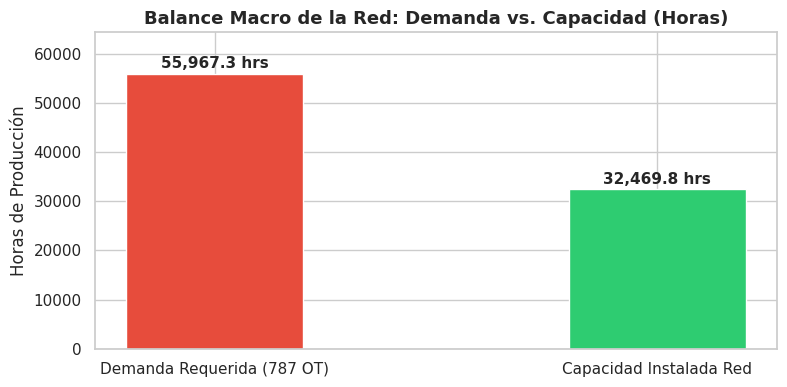

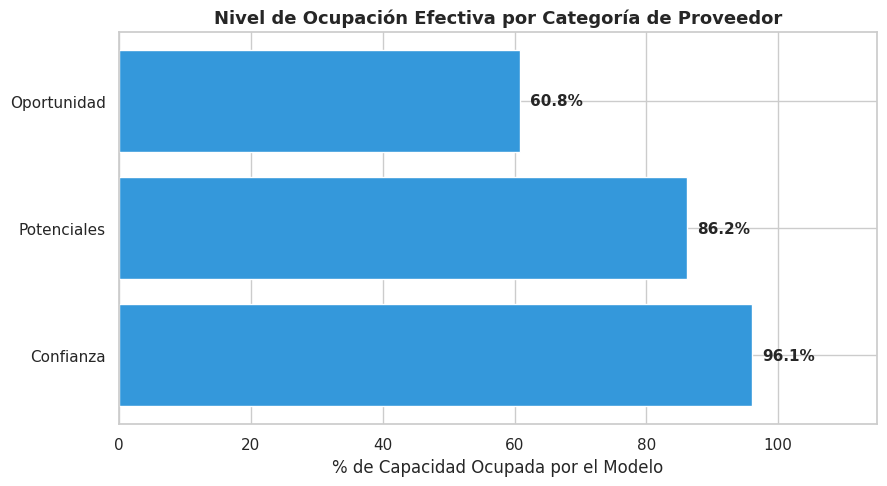

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual elegante
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# 1. GRÁFICO: BALANCE MACRO - DEMANDA VS CAPACIDAD
fig, ax = plt.subplots(figsize=(8, 4))
categorias = ['Demanda Requerida (787 OT)', 'Capacidad Instalada Red']
valores = [minutos_demanda_total / 60, minutos_capacidad_total / 60]  # En Horas
colores = ['#e74c3c', '#2ecc71']

bars = ax.bar(categorias, valores, color=colores, width=0.4)
ax.set_ylabel('Horas de Producción')
ax.set_title('Balance Macro de la Red: Demanda vs. Capacidad (Horas)', fontsize=13, fontweight='bold')

# Añadir etiquetas de texto sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 500, f'{yval:,.1f} hrs', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, max(valores) * 1.15)
plt.tight_layout()
plt.show()

# 2. GRÁFICO: USO DE CAPACIDAD POR CATEGORÍA DE PROVEEDOR
fig, ax = plt.subplots(figsize=(9, 5))

# Unir datos de oferta inicial con asignación real
df_cap_inicial = df_oferta_por_clasificacion.groupby('descripcion_clasificacion_proveedor')['capacidad_disponible'].sum().reset_index()
df_asig_cat = df_resultado.groupby('descripcion_clasificacion_proveedor')['minutos_totales_de_la_orden'].sum().reset_index()

df_graf_prov = df_cap_inicial.merge(df_asig_cat, on='descripcion_clasificacion_proveedor', how='left').fillna(0)
df_graf_prov.columns = ['categoria', 'capacidad_total', 'minutos_asignados']
df_graf_prov['pct_ocupacion'] = (df_graf_prov['minutos_asignados'] / df_graf_prov['capacidad_total']) * 100

df_graf_prov = df_graf_prov.sort_values(by='pct_ocupacion', ascending=False)

bars = ax.barh(df_graf_prov['categoria'].str.capitalize(), df_graf_prov['pct_ocupacion'], color='#3498db')
ax.set_xlabel('% de Capacidad Ocupada por el Modelo')
ax.set_title('Nivel de Ocupación Efectiva por Categoría de Proveedor', fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)

for bar in bars:
    xval = bar.get_width()
    ax.text(xval + 1.5, bar.get_y() + bar.get_height()/2.0, f'{xval:.1f}%', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.2. Insights y Evaluación del Plan Óptimo de Producción

A partir de la ejecución del modelo MIP en PuLP y la regla de secuenciación por taller, se obtienen las siguientes conclusiones ejecutivas del plan óptimo de producción:

* **Maximizacion del Nivel de Servicio (63.41% de Cobertura de Órdenes):**
  A pesar de la severa saturación inicial de la red ($172.37\%$ de carga global), el modelo logró asignar exitosamente **499 de las 787 órdenes de trabajo elegibles**, garantizando la entrega del **$41.93\%$ del volumen total de demanda en minutos** ($23,465.17$ horas de producción).

* **Enfoque en Urgencia Operativa (98.2% de Órdenes Asignadas son Prioridad 3):**
  El **$98.2\%$ de las órdenes asignadas** ($490$ de $499$ OT) corresponden a la categoría de **Prioridad 3 (mayor importancia)**, absorbiendo $1,346,789$ minutos de producción. Esto cumple directamente con el objetivo de minimizar el *Time to Market* de los lotes más críticos para el negocio.

* **Saturación Estratégica de Talleres de Confianza (96% de Uso):**
  El modelo demostró una alta sensibilidad hacia la calidad de la red: absorbió **$159,644.70$ minutos** en los talleres clasificados como **"Confianza"**, logrando una tasa de ocupación del **$96.06\%$** sobre la capacidad total disponible en esta categoría ($166,183$ min).

* **Secuenciación de Producción y Criterios LPT/SPT:**
  Dentro de la agenda de cada taller, las órdenes quedaron ordenadas priorizando estrictamente la urgencia ($P_3 \to P_2 \to P_1$) y minimizando el tiempo de proceso para acelerar la disponibilidad de producto terminado en el mercado.

In [ ]:
# Guardar el plan de producción secuenciado en un archivo CSV para entregar
df_plan_produccion.to_csv('Plan_Optimo_Produccion_Secuenciado.csv', index=False)
print("Archivo 'Plan_Optimo_Produccion_Secuenciado.csv' generado y listo para descarga")

Archivo 'Plan_Optimo_Produccion_Secuenciado.csv' generado y listo para descarga
